# CIFAR-10 Image Classification: Model Design and Implementation

For the **CIFAR-10 image classification task**, students are required to design and implement **three distinct custom CNN architectures** using **RGB input images** resized to a fixed dimension (e.g., **128 × 128 × 3**).



## CNN Model-1: Shallow CNN

This model focuses on simplicity and minimal depth.

**Architecture:**
- **Conv2D Layer**
  - Filters: 8  
  - Kernel size: 3 × 3  
  - Stride: 1  
  - Padding: None  
  - Activation: ReLU
- **Max-Pooling Layer**
  - Pool size: 2 × 2  
  - Stride: 2
- **Conv2D Layer**
  - Filters: 4  
  - Kernel size: 3 × 3  
  - Activation: ReLU
- **Max-Pooling Layer**
  - Pool size: 2 × 2  
  - Stride: 2
- **Flatten Layer**
- **Dense Layer**
  - Neurons: 8  
  - Activation: ReLU
- **Output Layer**
  - Suitable for CIFAR-10 classification (10 classes)

---

## CNN Model-2: Deeper CNN

This model increases representational capacity through additional depth and feature maps.

**Architecture:**
- **Conv2D Layer**
  - Filters: 16  
  - Kernel size: 3 × 3  
  - Activation: ReLU
- **Max-Pooling Layer**
  - Pool size: 2 × 2
- **Conv2D Layer**
  - Filters: 32  
  - Kernel size: 3 × 3  
  - Activation: ReLU
- **Max-Pooling Layer**
  - Pool size: 2 × 2
- **Conv2D Layer**
  - Filters: 64  
  - Kernel size: 3 × 3  
  - Activation: ReLU
- **Max-Pooling Layer**
  - Pool size: 2 × 2
- **Flatten Layer**
- **Dense Layer**
  - Neurons: 128  
  - Activation: ReLU
- **Dropout Layer**
  - Used for regularization
- **Output Layer**
  - Suitable for CIFAR-10 classification

---

## CNN Model-3: Enhanced CNN with Normalization and Larger Kernels

This model incorporates architectural enhancements to study their impact on performance.

**Architecture:**
- **Conv2D Layer**
  - Filters: 32  
  - Kernel size: 5 × 5  
  - Stride: 1
- **Batch Normalization**
- **ReLU Activation**
- **Max-Pooling Layer**
  - Pool size: 2 × 2
- **Conv2D Layer**
  - Filters: 64  
  - Kernel size: 3 × 3
- **Batch Normalization**
- **ReLU Activation**
- **Max-Pooling Layer**
  - Pool size: 2 × 2
- **Conv2D Layer**
  - Filters: 128  
  - Kernel size: 3 × 3  
  - Activation: ReLU
- **Max-Pooling Layer**
  - Pool size: 2 × 2
- **Flatten Layer**
- **Dense Layer**
  - Neurons: 256  
  - Activation: ReLU
- **Dropout Layer**
- **Dense Layer**
  - Neurons: 64  
  - Activation: ReLU
- **Dropout Layer**
- **Output Layer**
  - Suitable for CIFAR-10 classification

**Objective:**  
This configuration enables evaluation of the effects of increased depth, batch normalization, and larger receptive fields.

---

## Deep Neural Network (DNN) Model

In addition to CNNs, students must implement a **Deep Neural Network (DNN)** without convolutional or pooling layers.

**Architecture:**
- **Flatten Layer**
- **Dense Layer**
  - Neurons: 512  
  - Activation: ReLU
- **Dense Layer**
  - Neurons: 256  
  - Activation: ReLU
- **Dense Layer**
  - Neurons: 128  
  - Activation: ReLU
- **Output Layer**
  - Suitable for CIFAR-10 classification

---

## Training and Evaluation Requirements

- All **four models** must be trained **from scratch**
- Use the **same dataset split**, **optimizer**, **learning rate**, **batch size**, and **number of epochs**
- Models must be compared based on:
  - Training accuracy
  - Testing accuracy
  - Loss convergence
  - Number of parameters
  - Computational cost

**Results Presentation:**
- Training and validation **loss curves**
- Training and validation **accuracy curves**
- A concise **comparative discussion** highlighting strengths and weaknesses of each model


In [1]:
!pip install tensorflow

In [2]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import time

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [5]:
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [6]:
EPOCHS = 15
BATCH_SIZE = 32
LEARNING_RATE = 0.001

optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

In [7]:
input_shape=(32,32,3)

In [8]:
def build_cnn_model1():
    model = keras.Sequential([
        layers.Conv2D(8, (3,3), strides=1, activation='relu',
                      input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2), strides=2),

        layers.Conv2D(4, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2), strides=2),

        layers.Flatten(),
        layers.Dense(8, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [9]:
model1 = build_cnn_model1()

model1.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 4)      │           292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,766 (6.90 KB)

 Trainable params: 1,766 (6.90 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
start = time.time()

history1 = model1.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

end = time.time()

print("Training Time (Model 1):", round(end-start, 2), "seconds")

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.2164 - loss: 2.0613 - val_accuracy: 0.3661 - val_loss: 1.7100
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3722 - loss: 1.6850 - val_accuracy: 0.3969 - val_loss: 1.6111
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4038 - loss: 1.6149 - val_accuracy: 0.4188 - val_loss: 1.5669
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4176 - loss: 1.5638 - val_accuracy: 0.4258 - val_loss: 1.5339
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4311 - loss: 1.5303 - val_accuracy: 0.4314 - val_loss: 1.5282
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.4320 - loss: 1.5199 - val_accuracy: 0.4451 - val_loss: 1.4936
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4422 - loss: 1.5035 - val_accuracy: 0.4375 - val_loss: 1.5133
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.4423 - loss: 1.5030

In [11]:
def build_cnn_model2():
    model = keras.Sequential([
        layers.Conv2D(16, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [12]:
model2 = build_cnn_model2()

model2.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,304 (239.47 KB)

 Trainable params: 57,770 (225.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,534 (13.81 KB)

In [13]:
optimizer2 = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model2.compile(
    optimizer=optimizer2,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
start = time.time()

history2 = model2.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

end = time.time()

print("Training Time (Model 2):", round(end-start, 2), "seconds")

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.2884 - loss: 1.9066 - val_accuracy: 0.4742 - val_loss: 1.4451
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4967 - loss: 1.3907 - val_accuracy: 0.5585 - val_loss: 1.2368
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5567 - loss: 1.2442 - val_accuracy: 0.6012 - val_loss: 1.1340
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5951 - loss: 1.1463 - val_accuracy: 0.6231 - val_loss: 1.0570
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6210 - loss: 1.0765 - val_accuracy: 0.6272 - val_loss: 1.0391
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6479 - loss: 1.0036 - val_accuracy: 0.6541 - val_loss: 0.9744
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6601 - loss: 0.9744 - val_accuracy: 0.6602 - val_loss: 0.9782
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6719 - loss: 0.9436 -

In [15]:
def build_cnn_model3():
    model = keras.Sequential([
        layers.Conv2D(32, (5,5), input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [16]:
optimizer3 = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model3 = build_cnn_model3()

model3.compile(
    optimizer=optimizer3,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,594 (951.54 KB)

 Trainable params: 243,402 (950.79 KB)

 Non-trainable params: 192 (768.00 B)

In [17]:
start = time.time()

history3 = model3.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

end = time.time()

print("Training Time (Model 3):", round(end-start, 2), "seconds")

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.2606 - loss: 1.9827 - val_accuracy: 0.4453 - val_loss: 1.5180
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4704 - loss: 1.4664 - val_accuracy: 0.4837 - val_loss: 1.4651
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5528 - loss: 1.2825 - val_accuracy: 0.5713 - val_loss: 1.1965
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5931 - loss: 1.1744 - val_accuracy: 0.6017 - val_loss: 1.1390
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6246 - loss: 1.0994 - val_accuracy: 0.5064 - val_loss: 1.3956
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6447 - loss: 1.0365 - val_accuracy: 0.6405 - val_loss: 1.0169
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6597 - loss: 0.9934 - val_accuracy: 0.5729 - val_loss: 1.2490
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6753 - loss: 0.9485 -

In [18]:
def build_dnn():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [19]:
optimizer4 = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model4 = build_dnn()

model4.compile(
    optimizer=optimizer4,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
start = time.time()

history4 = model4.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

end = time.time()

print("Training Time (DNN):", round(end-start, 2), "seconds")

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.2702 - loss: 2.0116 - val_accuracy: 0.3607 - val_loss: 1.7493
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3848 - loss: 1.7022 - val_accuracy: 0.4105 - val_loss: 1.6491
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4213 - loss: 1.6105 - val_accuracy: 0.4404 - val_loss: 1.5711
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4469 - loss: 1.5463 - val_accuracy: 0.4482 - val_loss: 1.5548
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4599 - loss: 1.4986 - val_accuracy: 0.4620 - val_loss: 1.5077
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4740 - loss: 1.4686 - val_accuracy: 0.4476 - val_loss: 1.5352
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4811 - loss: 1.4491 - val_accuracy: 0.4723 - val_loss: 1.4802
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4944 - loss: 1.4104 - 

In [21]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(['Train','Validation'])

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(['Train','Validation'])

    plt.show()

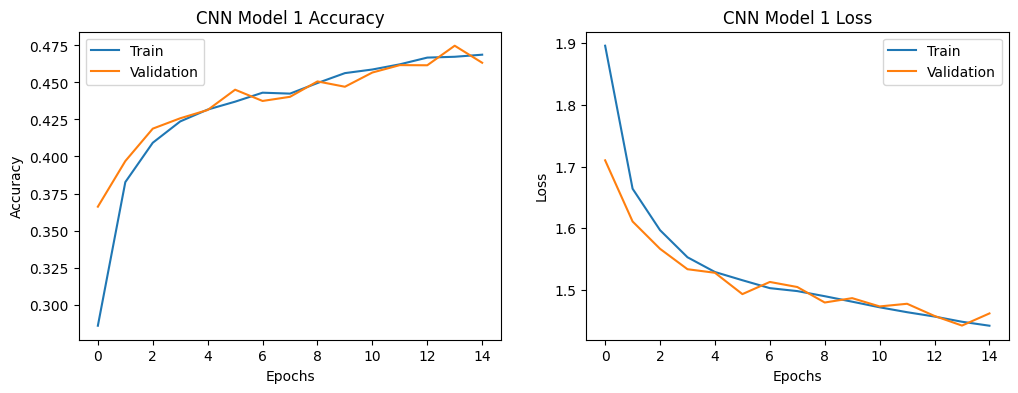

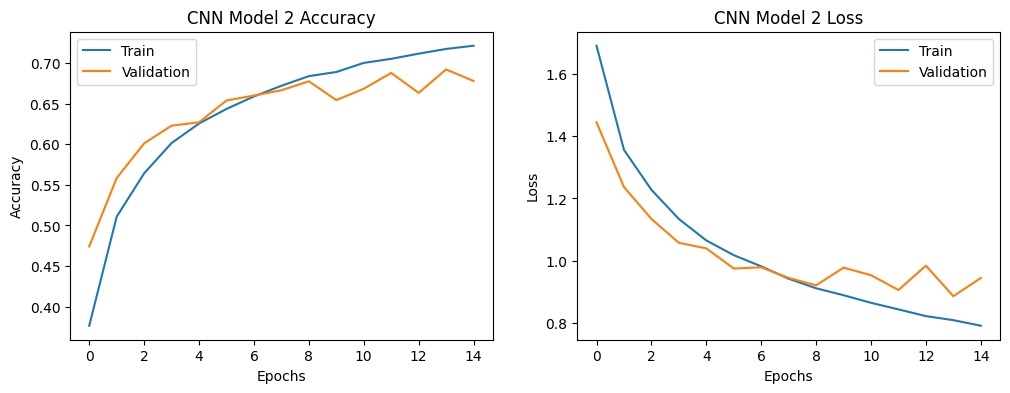

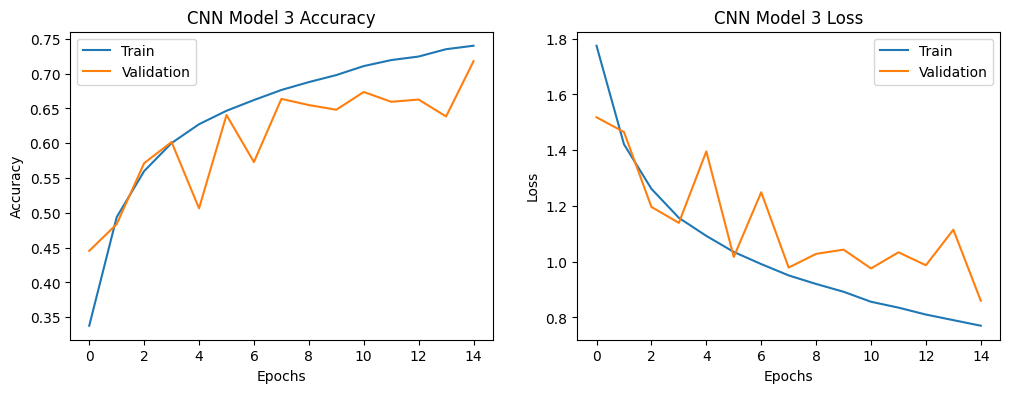

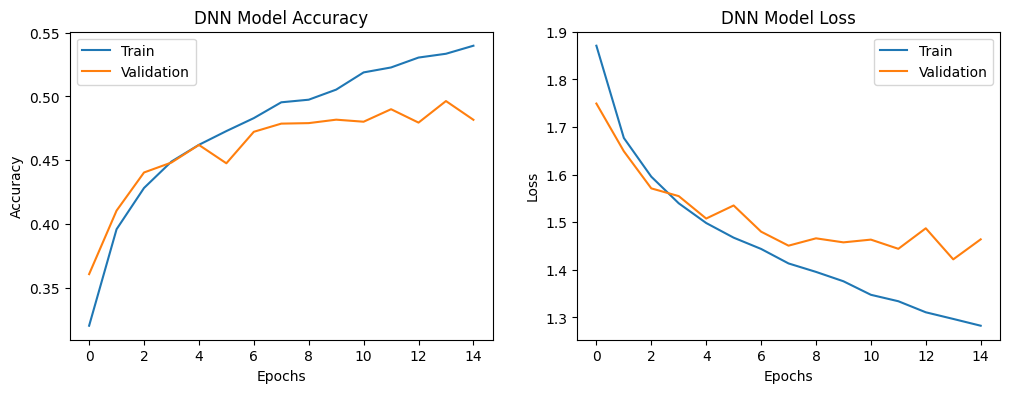

In [22]:
plot_history(history1, "CNN Model 1")
plot_history(history2, "CNN Model 2")
plot_history(history3, "CNN Model 3")
plot_history(history4, "DNN Model")

In [23]:
print("Model 1 Parameters:", model1.count_params())
print("Model 2 Parameters:", model2.count_params())
print("Model 3 Parameters:", model3.count_params())
print("DNN Parameters:", model4.count_params())

Model 1 Parameters: 1766
Model 2 Parameters: 57770
Model 3 Parameters: 243594
DNN Parameters: 1738890


In [24]:
print("Model 1 Test Accuracy:", history1.history['val_accuracy'][-1])
print("Model 2 Test Accuracy:", history2.history['val_accuracy'][-1])
print("Model 3 Test Accuracy:", history3.history['val_accuracy'][-1])
print("DNN Test Accuracy:", history4.history['val_accuracy'][-1])

Model 1 Test Accuracy: 0.4632999897003174
Model 2 Test Accuracy: 0.6782000064849854
Model 3 Test Accuracy: 0.7178000211715698
DNN Test Accuracy: 0.48170000314712524
